In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [7]:
data = pd.read_csv("diabetes_dataset.csv")

print(data.head())
print(data.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [8]:
print(data.info())
print(data.isnull().sum())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                      

In [9]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print(X.head())
print(y.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [11]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7077922077922078

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



In [12]:
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Confusion Matrix:
[[74 26]
 [19 35]]


In [13]:
svm = SVC(kernel="linear")

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7207792207792207

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



In [14]:
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Confusion Matrix:
[[83 17]
 [26 28]]


In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7012987012987013

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [16]:
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Confusion Matrix:
[[80 20]
 [26 28]]


In [17]:
results = pd.DataFrame({
    'Algorithm': ['Naive Bayes', 'SVM', 'KNN'],
    'Accuracy': [accuracy_nb, accuracy_svm, accuracy_knn]
})

best_algorithm = results.loc[
    results["Accuracy"].idxmax(), "Algorithm"
]

print("Best Algorithm:", best_algorithm)

Best Algorithm: SVM


In [18]:
new_patient = np.array([[2, 120, 70, 30, 100, 32, 0.5, 35]])

new_patient_scaled = scaler.transform(new_patient)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
prediction_nb = nb.predict(new_patient_scaled)

if prediction_nb[0] == 1:
    print("Naive Bayes: Diabetes predicted")
else:
    print("Naive Bayes: No diabetes predicted")

Naive Bayes: No diabetes predicted


In [20]:
prediction_svm = svm.predict(new_patient_scaled)

if prediction_svm[0] == 1:
    print("SVM: Diabetes predicted")
else:
    print("SVM: No diabetes predicted")

SVM: No diabetes predicted


In [21]:
prediction_knn = knn.predict(new_patient_scaled)

if prediction_knn[0] == 1:
    print("KNN: Diabetes predicted")
else:
    print("KNN: No diabetes predicted")

KNN: Diabetes predicted


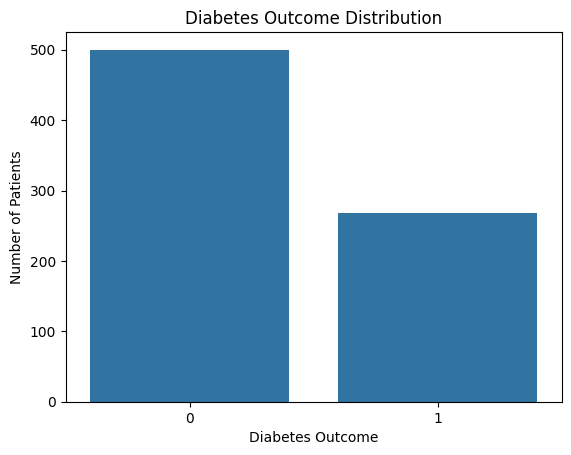

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Patients")
plt.show()

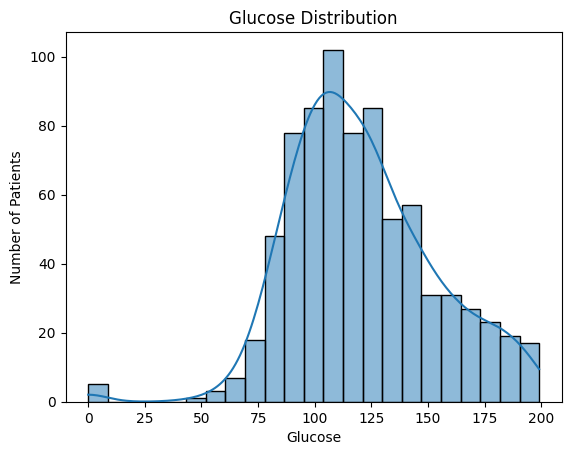

In [23]:
sns.histplot(data=data, x="Glucose", kde=True)

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.show()

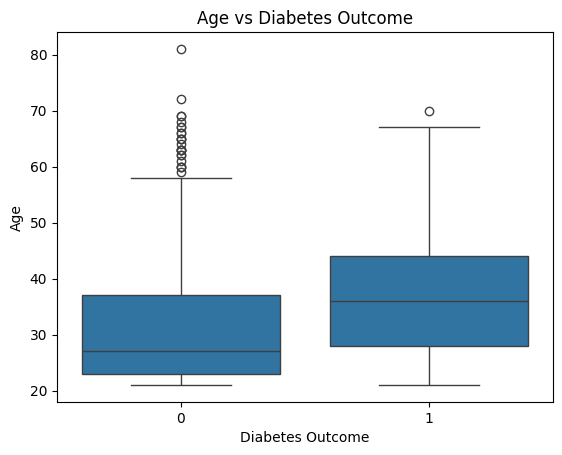

In [24]:
sns.boxplot(
    data=data,
    x="Outcome",
    y="Age"
)

plt.title("Age vs Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Age")
plt.show()

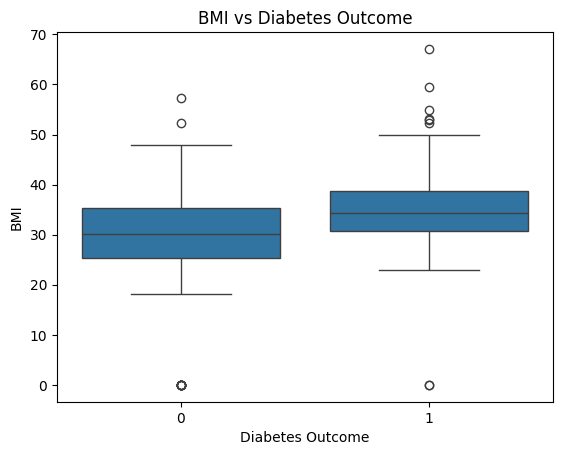

In [25]:
sns.boxplot(
    data=data,
    x="Outcome",
    y="BMI"
)

plt.title("BMI vs Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("BMI")
plt.show()

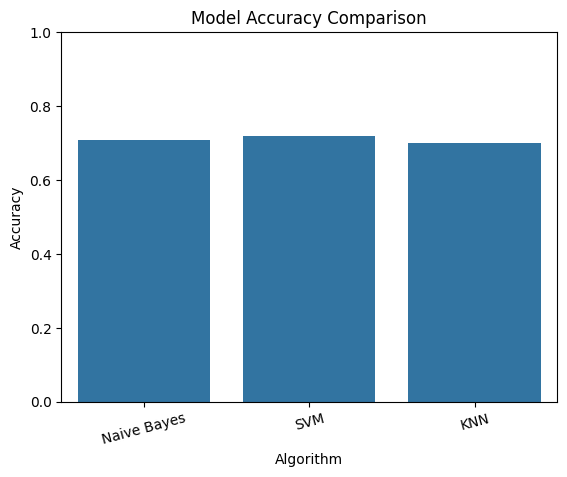

In [26]:
sns.barplot(
    data=results,
    x="Algorithm",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

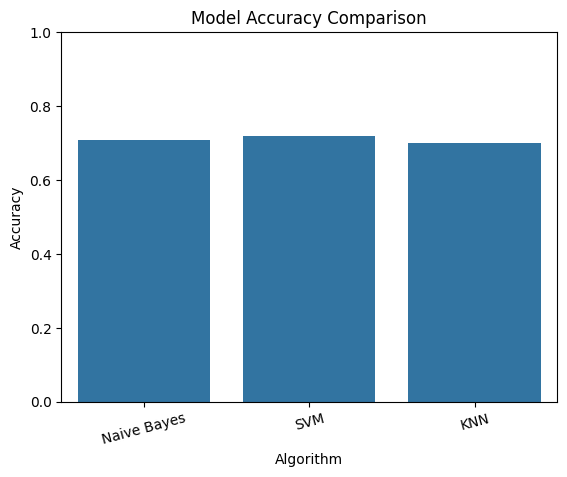

In [27]:
sns.barplot(
    data=results,
    x="Algorithm",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

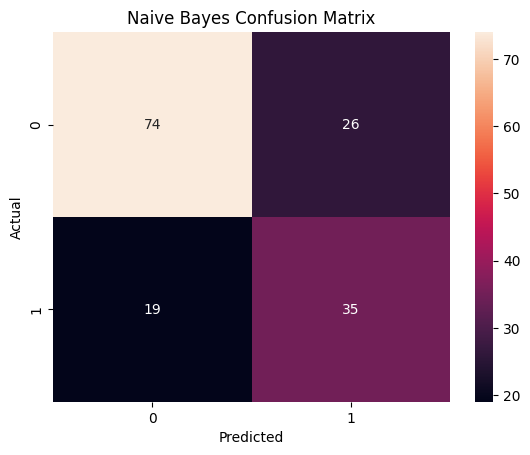

In [28]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

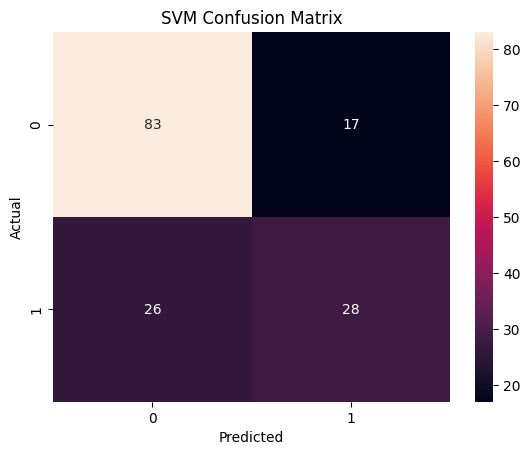

In [29]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

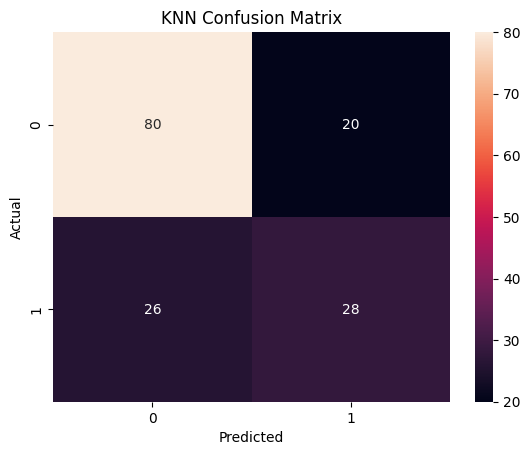

In [30]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()